In [13]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


In [2]:
nodes = pd.read_csv("InputFileNodes.csv")
edges = pd.read_csv("InputFileEdges.csv")

In [30]:
nodes.head(20)

,id,media,media.type,type.label,audience.size
0,s01,NY Times,1,Newspaper,20
1,s02,Washington Post,1,Newspaper,25
2,s03,Wall Street Journal,1,Newspaper,30
3,s04,USA Today,1,Newspaper,32
4,s05,LA Times,1,Newspaper,20
5,s06,New York Post,1,Newspaper,50
6,s07,CNN,2,TV,56
7,s08,MSNBC,2,TV,34
8,s09,FOX News,2,TV,60
9,s10,ABC,2,TV,23


In [4]:
edges.head()

,from,to,weight,type
0,s01,s02,10,hyperlink
1,s01,s02,12,hyperlink
2,s01,s03,22,hyperlink
3,s01,s04,21,hyperlink
4,s04,s11,22,mention


In [18]:
df = pd.merge(nodes,edges,left_on = 'id',right_on = 'from',how='inner')

In [19]:
df.head()

,id,media,media.type,type.label,audience.size,from,to,weight,type
0,s01,NY Times,1,Newspaper,20,s01,s02,10,hyperlink
1,s01,NY Times,1,Newspaper,20,s01,s02,12,hyperlink
2,s01,NY Times,1,Newspaper,20,s01,s03,22,hyperlink
3,s01,NY Times,1,Newspaper,20,s01,s04,21,hyperlink
4,s01,NY Times,1,Newspaper,20,s01,s15,20,mention


In [25]:
new_df = pd.merge(df,nodes,left_on = 'to',right_on = 'id',how='inner')

In [29]:
new_df.head(20)

,id_x,media_x,media.type_x,type.label_x,audience.size_x,from,to,weight,type,id_y,media_y,media.type_y,type.label_y,audience.size_y
0,s01,NY Times,1,Newspaper,20,s01,s02,10,hyperlink,s02,Washington Post,1,Newspaper,25
1,s01,NY Times,1,Newspaper,20,s01,s02,12,hyperlink,s02,Washington Post,1,Newspaper,25
2,s01,NY Times,1,Newspaper,20,s01,s03,22,hyperlink,s03,Wall Street Journal,1,Newspaper,30
3,s01,NY Times,1,Newspaper,20,s01,s04,21,hyperlink,s04,USA Today,1,Newspaper,32
4,s01,NY Times,1,Newspaper,20,s01,s15,20,mention,s15,NYTimes.com,3,Online,24
5,s02,Washington Post,1,Newspaper,25,s02,s03,21,hyperlink,s03,Wall Street Journal,1,Newspaper,30
6,s02,Washington Post,1,Newspaper,25,s02,s01,23,hyperlink,s01,NY Times,1,Newspaper,20
7,s02,Washington Post,1,Newspaper,25,s02,s10,5,hyperlink,s10,ABC,2,TV,23
8,s02,Washington Post,1,Newspaper,25,s02,s09,1,hyperlink,s09,FOX News,2,TV,60
9,s03,Wall Street Journal,1,Newspaper,30,s03,s04,22,hyperlink,s04,USA Today,1,Newspaper,32


In [31]:
gr = nx.from_pandas_edgelist(new_df,source='media_x',target='media_y',edge_attr=['weight','type'])

In [33]:
print(new_df['type'].unique())

['hyperlink' 'mention']


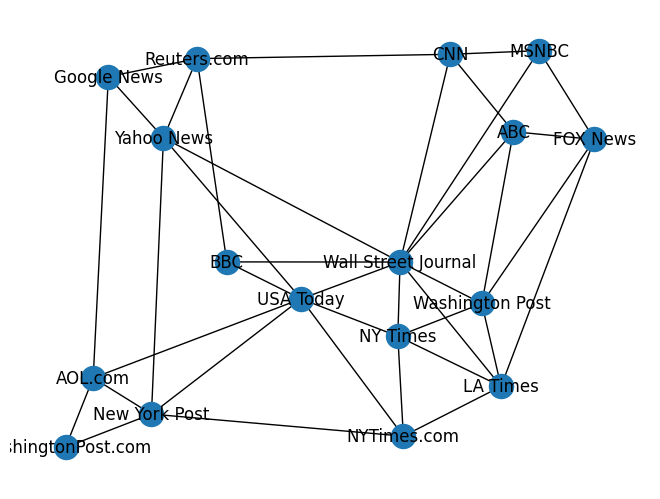

In [36]:
nx.draw(gr,with_labels=True)
plt.show()

In [39]:
[v * 750 for v in dict(gr.degree()).values()]

[3750,
 3750,
 6750,
 5250,
 3000,
 3000,
 3000,
 3750,
 2250,
 2250,
 3750,
 3750,
 3000,
 1500,
 3000,
 3000,
 2250]

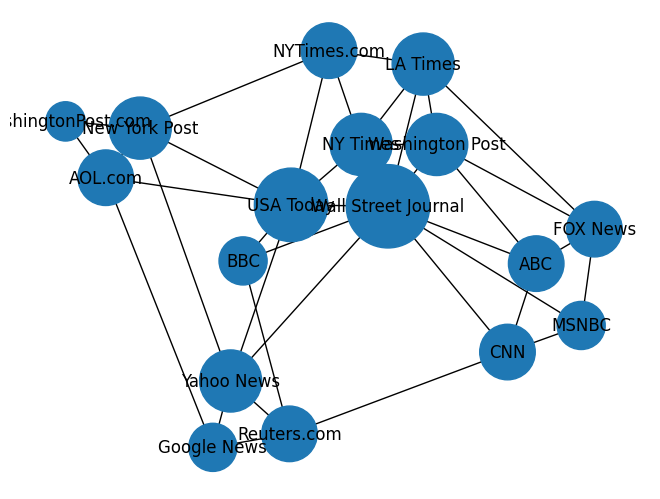

In [47]:
nx.draw_spring(gr,with_labels=True,node_size=[v * 400 for v in dict(gr.degree()).values()])
plt.show()

In [49]:
edgelist = nx.to_edgelist(gr)
print(edgelist)

[('NY Times', 'Washington Post', {'weight': 23, 'type': 'hyperlink'}), ('NY Times', 'Wall Street Journal', {'weight': 21, 'type': 'hyperlink'}), ('NY Times', 'USA Today', {'weight': 21, 'type': 'hyperlink'}), ('NY Times', 'NYTimes.com', {'weight': 11, 'type': 'hyperlink'}), ('NY Times', 'LA Times', {'weight': 1, 'type': 'mention'}), ('Washington Post', 'Wall Street Journal', {'weight': 21, 'type': 'hyperlink'}), ('Washington Post', 'ABC', {'weight': 5, 'type': 'hyperlink'}), ('Washington Post', 'FOX News', {'weight': 1, 'type': 'hyperlink'}), ('Washington Post', 'LA Times', {'weight': 21, 'type': 'hyperlink'}), ('Wall Street Journal', 'USA Today', {'weight': 23, 'type': 'hyperlink'}), ('Wall Street Journal', 'Yahoo News', {'weight': 1, 'type': 'hyperlink'}), ('Wall Street Journal', 'ABC', {'weight': 2, 'type': 'hyperlink'}), ('Wall Street Journal', 'BBC', {'weight': 1, 'type': 'hyperlink'}), ('Wall Street Journal', 'MSNBC', {'weight': 2, 'type': 'hyperlink'}), ('Wall Street Journal', '

In [68]:
edge_colors = [v[2]['type'] for v in edgelist]
edge_label = edge_colors
for i in range (len(edge_colors)):
    if edge_colors[i] == 'hyperlink':
        edge_colors[i] = 'blue'
    else:
        edge_colors[i] = 'red' 
print(edge_colors)           

['blue', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'red', 'blue', 'red', 'blue', 'red', 'red', 'red', 'red', 'red', 'blue', 'red', 'red', 'red', 'red']


In [69]:
edge_weights = [v[2]['weight']/5 for v in edgelist]
print(edge_weights)

[4.6, 4.2, 4.2, 2.2, 0.2, 4.2, 1.0, 0.2, 4.2, 4.6, 0.2, 0.4, 0.2, 0.4, 0.2, 0.2, 4.4, 0.2, 0.6, 0.8, 0.2, 4.2, 0.8, 4.2, 4.2, 0.4, 2.4, 4.2, 4.4, 0.4, 0.2, 4.2, 4.2, 4.6, 0.2, 4.2, 0.8, 4.2]


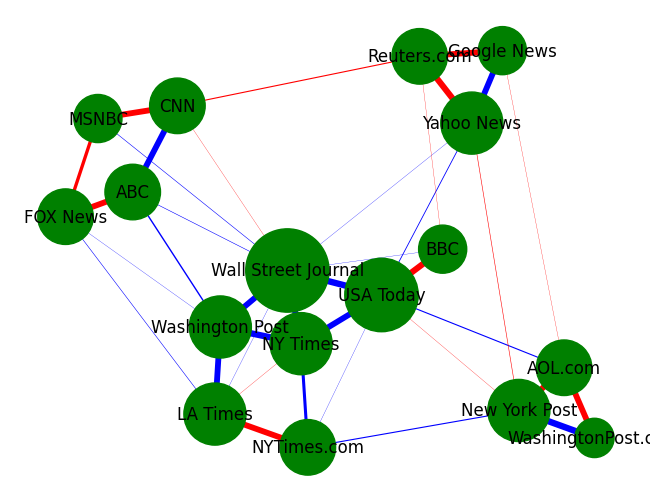

In [87]:
nx.draw_spring(gr,
with_labels=True,
node_color = 'green',
node_size=[v * 400 for v in dict(gr.degree()).values()],
width = edge_weights,
edge_color = edge_colors)
plt.show()

In [83]:
dc = nx.degree_centrality(gr)
for i in sorted(dc,key=dc.get,reverse=True):
    print(i,dc[i])

Wall Street Journal 0.5625
USA Today 0.4375
NY Times 0.3125
Washington Post 0.3125
Yahoo News 0.3125
LA Times 0.3125
New York Post 0.3125
NYTimes.com 0.25
ABC 0.25
FOX News 0.25
AOL.com 0.25
CNN 0.25
Reuters.com 0.25
BBC 0.1875
MSNBC 0.1875
Google News 0.1875
WashingtonPost.com 0.125


In [84]:
bc=nx.betweenness_centrality(gr)
for i in sorted(bc,key=dc.get,reverse=True):
    print(i,bc[i])

Wall Street Journal 0.3404166666666666
USA Today 0.19566468253968256
NY Times 0.039146825396825395
Washington Post 0.025992063492063493
Yahoo News 0.12271825396825395
LA Times 0.0654563492063492
New York Post 0.10018849206349206
NYTimes.com 0.05621031746031746
ABC 0.025843253968253963
FOX News 0.01736111111111111
AOL.com 0.05293650793650794
CNN 0.050277777777777775
Reuters.com 0.04916666666666667
BBC 0.017916666666666664
MSNBC 0.019593253968253965
Google News 0.02111111111111111
WashingtonPost.com 0.0


In [85]:
ec=nx.eigenvector_centrality(gr)
for i in sorted(ec,key=dc.get,reverse=True):
    print(i,ec[i])

Wall Street Journal 0.44854729796753545
USA Today 0.35283346117368625
NY Times 0.3191408683729161
Washington Post 0.2910340882293078
Yahoo News 0.248809538829334
LA Times 0.29255252705287443
New York Post 0.20688820586442142
NYTimes.com 0.23130251528184956
ABC 0.22209545169996198
FOX News 0.19159229230644556
AOL.com 0.1452821366686579
CNN 0.1936188619934287
Reuters.com 0.14530038460965825
BBC 0.18692750129523708
MSNBC 0.16462950341222413
Google News 0.1065065446362404
WashingtonPost.com 0.06953859174549203


In [86]:
cc=nx.closeness_centrality(gr)
for i in sorted(cc,key=dc.get,reverse=True):
    print(i,cc[i])

Wall Street Journal 0.6666666666666666
USA Today 0.6153846153846154
NY Times 0.5333333333333333
Washington Post 0.48484848484848486
Yahoo News 0.5714285714285714
LA Times 0.5161290322580645
New York Post 0.5
NYTimes.com 0.48484848484848486
ABC 0.47058823529411764
FOX News 0.41025641025641024
AOL.com 0.45714285714285713
CNN 0.48484848484848486
Reuters.com 0.47058823529411764
BBC 0.5161290322580645
MSNBC 0.45714285714285713
Google News 0.43243243243243246
WashingtonPost.com 0.35555555555555557


In [89]:
import networkx.algorithms.community as nx_comm


In [91]:
lcom = nx_comm.louvain_communities(gr)
print(lcom)

[{'Yahoo News', 'Google News', 'Reuters.com'}, {'ABC', 'MSNBC', 'FOX News', 'CNN'}, {'BBC', 'LA Times', 'NY Times', 'Washington Post', 'NYTimes.com', 'USA Today', 'Wall Street Journal'}, {'New York Post', 'WashingtonPost.com', 'AOL.com'}]


In [92]:
gcom = nx_comm.greedy_modularity_communities(gr)
print(gcom)

[frozenset({'LA Times', 'FOX News', 'Washington Post', 'Wall Street Journal', 'CNN', 'NY Times', 'MSNBC', 'ABC'}), frozenset({'New York Post', 'WashingtonPost.com', 'AOL.com', 'NYTimes.com', 'USA Today'}), frozenset({'BBC', 'Yahoo News', 'Google News', 'Reuters.com'})]
